<a href="https://colab.research.google.com/github/sebz04/simple_MLP/blob/main/SimpleMLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Core data libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Model evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# For feature importance after training the neural network
from sklearn.inspection import permutation_importance

# For saving model objects later
import joblib

# Helps make results reproducible
RANDOM_STATE = 42

## 1. Load the Final Dataset

This project uses the cleaned county-year gun violence dataset created by our group.  
Each row represents one U.S. county in one year.  

The target variable is `violence_level`, which labels each county-year as:

- `high`: crude firearm death rate is at or above the median threshold
- `low`: crude firearm death rate is below the median threshold

My individual model is a simple neural network, specifically a Multi-Layer Perceptron classifier.

In [ ]:
# Load the dataset that already includes the high/low violence label
df = pd.read_csv("gun_violence_with_levels.csv")

# Display the first few rows to confirm the file loaded correctly
df.head()

,FIPS,year,deaths,population,crude_rate,was_suppressed,yoy_pct_change,spike,svi_unemp_rate,svi_no_hs_diploma,...,RPL_THEME2,RPL_THEME3,RPL_THEME4,RPL_THEMES,svi_poverty_rate,svi_housing_burden,acs_poverty_rate,acs_unemp_rate,acs_median_income,violence_level
0,1001,2019,5.0,55869.0,8.949507,1,-0.479694,0,4.2,11.3,...,0.5810,0.5947,0.3741,0.4354,15.4,22.4,15.185172,3.676644,58731.0,low
1,1001,2020,5.0,56145.0,8.905513,1,-0.491584,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,23.3,15.211758,2.907252,57982.0,low
2,1001,2021,12.0,59095.0,20.306286,0,128.019291,1,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,23.3,13.578474,2.824625,62660.0,low
3,1001,2022,14.0,59759.0,23.427434,0,15.370349,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,23.3,11.373969,2.768472,68315.0,high
4,1001,2023,12.0,60342.0,19.886646,0,-15.113851,0,2.9,11.3,...,0.7362,0.6337,0.4309,0.5130,22.9,23.3,10.684306,2.541559,69841.0,low


In [ ]:
# Check the shape of the dataset
# This tells us how many rows and columns we are working with
print("Dataset shape:", df.shape)

Dataset shape: (13328, 33)


In [ ]:
# View all column names
# This helps us understand what variables are available for modeling
df.columns.tolist()

['FIPS',
 'year',
 'deaths',
 'population',
 'crude_rate',
 'was_suppressed',
 'yoy_pct_change',
 'spike',
 'svi_unemp_rate',
 'svi_no_hs_diploma',
 'svi_uninsured',
 'svi_age65_plus',
 'svi_age17_under',
 'svi_disabled',
 'svi_single_parent',
 'svi_minority',
 'svi_limited_english',
 'svi_multi_unit',
 'svi_mobile_homes',
 'svi_crowded_housing',
 'svi_no_vehicle',
 'svi_group_quarters',
 'RPL_THEME1',
 'RPL_THEME2',
 'RPL_THEME3',
 'RPL_THEME4',
 'RPL_THEMES',
 'svi_poverty_rate',
 'svi_housing_burden',
 'acs_poverty_rate',
 'acs_unemp_rate',
 'acs_median_income',
 'violence_level']

In [ ]:
# Check the target variable distribution
# Since the target was created using a median split, we expect it to be roughly balanced
df["violence_level"].value_counts()

,count
violence_level,
high,6665
low,6663


In [ ]:
# Check the target variable distribution as percentages
df["violence_level"].value_counts(normalize=True).round(3)

,proportion
violence_level,
high,0.5
low,0.5


## 2. Data Preparation and Leakage Removal

Before training the neural network, we must carefully prepare the dataset.

### Why this step is critical:
In predictive modeling, we must avoid **data leakage**, which occurs when features directly or indirectly reveal the target variable. This leads to unrealistically high model performance that would not generalize in real-world scenarios.

In this project, the target variable `violence_level` is derived from the crude firearm death rate. Therefore, any variables closely related to this rate must be removed.

### Leakage columns removed:
- `deaths` → directly used to compute crude rate  
- `crude_rate` → used to define high vs low violence  
- `yoy_pct_change` → derived from death rates  
- `spike` → likely tied to sudden increases in violence  

We also remove identifiers that should not be used for prediction:
- `FIPS` → geographic identifier (used only for grouping)
- `year` → could introduce temporal leakage patterns

After cleaning, we separate:
- **X (features)** → socioeconomic + SVI + ACS variables  
- **y (target)** → high vs low violence classification

In [ ]:
# Make a copy so we don't accidentally modify the original dataset
df_model = df.copy()

# Define columns to remove (leakage + identifiers)
leakage_cols = [
    "deaths",
    "crude_rate",
    "yoy_pct_change",
    "spike",
    "FIPS",
    "year"
]

# Drop columns that exist in the dataset
df_model = df_model.drop(columns=[col for col in leakage_cols if col in df_model.columns])

# Confirm columns removed
print("Remaining columns:", len(df_model.columns))
df_model.columns.tolist()

Remaining columns: 27


['population',
 'was_suppressed',
 'svi_unemp_rate',
 'svi_no_hs_diploma',
 'svi_uninsured',
 'svi_age65_plus',
 'svi_age17_under',
 'svi_disabled',
 'svi_single_parent',
 'svi_minority',
 'svi_limited_english',
 'svi_multi_unit',
 'svi_mobile_homes',
 'svi_crowded_housing',
 'svi_no_vehicle',
 'svi_group_quarters',
 'RPL_THEME1',
 'RPL_THEME2',
 'RPL_THEME3',
 'RPL_THEME4',
 'RPL_THEMES',
 'svi_poverty_rate',
 'svi_housing_burden',
 'acs_poverty_rate',
 'acs_unemp_rate',
 'acs_median_income',
 'violence_level']

In [ ]:
# Define target variable
y = df_model["violence_level"]

# Define feature set (drop target column)
X = df_model.drop(columns=["violence_level"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (13328, 26)
Target shape: (13328,)


In [ ]:
# Convert 'high' → 1, 'low' → 0
y = y.map({"low": 0, "high": 1})

# Confirm conversion
y.value_counts()

,count
violence_level,
1,6665
0,6663


### Train-Test Split Strategy

We use **GroupShuffleSplit based on FIPS codes**.

Why?

If we randomly split rows, the same county could appear in both training and test sets (just in different years). This would cause **data leakage across time**, leading to overly optimistic performance.

By grouping on `FIPS`, we ensure:
- Counties in training set do NOT appear in test set
- The model is evaluated on completely unseen counties

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Extract groups (FIPS from original df)
groups = df["FIPS"]

# Initialize split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# Perform split
for train_idx, test_idx in gss.split(X, y, groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (10681, 26)
Test shape: (2647, 26)


### Feature Scaling

Neural networks are sensitive to the scale of input features.

We apply **StandardScaler**, which:
- Centers features around 0
- Scales them to unit variance

This ensures faster convergence and better performance of the MLP.

In [ ]:
# Initialize scaler
scaler = StandardScaler()

# Fit ONLY on training data (important!)
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (10681, 26)


## 3. Model Choice: Neural Network (MLP)

For my individual model, I selected a **Neural Network using a Multi-Layer Perceptron (MLP)**.

### Why Neural Networks?

Neural networks are powerful models that can capture **complex, nonlinear relationships** between variables. In this project, we are using a dataset with many socioeconomic and social vulnerability indicators (SVI + ACS features), which may interact with each other in non-obvious ways.

Unlike linear models (such as Logistic Regression), which assume a linear relationship between features and the target, neural networks can learn:

- Nonlinear patterns  
- Interactions between multiple variables  
- Hidden relationships that are not explicitly defined  

### Why MLP specifically?

A Multi-Layer Perceptron (MLP) is a **feedforward neural network** consisting of:
- An input layer (our features)
- One or more hidden layers
- An output layer (binary classification: high vs low violence)

For this project, we use a **simple MLP architecture** because:
- The dataset is tabular (not images or text)
- The assignment requires a "simple neural network"
- It provides a strong comparison against tree-based models and logistic regression

### Strengths of MLP for this problem:
- Captures complex feature interactions
- Flexible model structure
- Can outperform linear models if relationships are nonlinear

### Limitations:
- Less interpretable than Logistic Regression
- Requires feature scaling
- Can overfit if not tuned properly

### Role in Team Model Comparison:
The neural network provides a **contrast to tree-based models (Random Forest, XGBoost)** and linear models (Logistic Regression), helping the team evaluate whether nonlinear deep patterns improve predictive performance.

## 4. Baseline Neural Network Model (MLP)

In this section, we build a **baseline Multi-Layer Perceptron (MLP)** model.

A baseline model is an initial version of the model with reasonable default settings. It allows us to:
- Establish a performance benchmark
- Identify areas for improvement
- Guide hyperparameter tuning in later steps

### Model Setup

We use `MLPClassifier` from scikit-learn with:
- One hidden layer
- A moderate number of neurons
- Default activation function (ReLU)

This simple structure is appropriate for:
- Tabular data
- Binary classification
- Initial experimentation before tuning

Later, we will improve performance through hyperparameter tuning.

In [ ]:
# Initialize a baseline MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),   # One hidden layer with 50 neurons
    activation='relu',          # ReLU activation function
    solver='adam',              # Optimizer
    alpha=0.0001,               # L2 regularization term
    learning_rate='adaptive',   # Adjust learning rate during training
    max_iter=500,               # Number of training iterations
    random_state=RANDOM_STATE
)

In [ ]:
# Train the model on scaled training data
mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(50,), learning_rate='adaptive', max_iter=500,
              random_state=42)

In [ ]:
# Predict class labels
y_pred = mlp.predict(X_test_scaled)

# Predict probabilities (needed for ROC-AUC)
y_prob = mlp.predict_proba(X_test_scaled)[:, 1]

## 5. Model Evaluation

We evaluate the neural network using multiple performance metrics:

- **Accuracy** → Overall correctness
- **Precision** → How many predicted high-violence counties are actually high
- **Recall** → How many actual high-violence counties we correctly identify  
  (Important: Missing a high-risk county is costly in this context)
- **F1 Score** → Balance between precision and recall
- **ROC-AUC** → Overall model discrimination ability
- **Confusion Matrix** → Breakdown of predictions

In this problem, **recall is especially important**, because failing to identify a high-risk county could prevent critical intervention.

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Baseline MLP Performance:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

Baseline MLP Performance:
Accuracy:  0.895
Precision: 0.896
Recall:    0.887
F1 Score:  0.892
ROC-AUC:   0.968


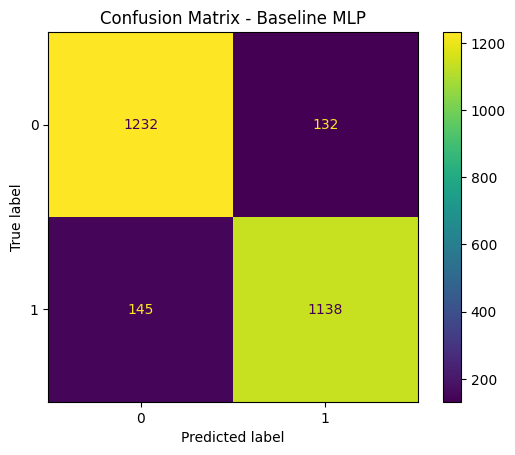

In [ ]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Baseline MLP")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1364
           1       0.90      0.89      0.89      1283

    accuracy                           0.90      2647
   macro avg       0.90      0.90      0.90      2647
weighted avg       0.90      0.90      0.90      2647



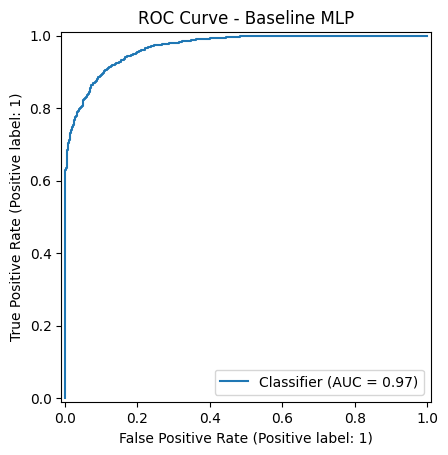

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Baseline MLP")
plt.show()

### Baseline Model Insights

The baseline MLP model demonstrates strong performance across all evaluation metrics, with an accuracy of approximately 89.5% and an ROC-AUC of 0.968.

The model maintains a good balance between precision (0.896) and recall (0.887), indicating that it is effective at both identifying high-risk counties and minimizing false alarms.

Recall is especially important in this context, as failing to identify a high-risk county could prevent timely intervention. The model successfully captures nearly 89% of high-violence counties, which suggests strong practical utility.

The ROC-AUC score of 0.968 indicates excellent class separation, meaning the model is highly effective at distinguishing between high and low violence counties across different decision thresholds.

Overall, this baseline neural network provides a strong starting point for further optimization through hyperparameter tuning.

## 6. Hyperparameter Tuning

The baseline MLP model performed strongly, but neural networks are sensitive to model settings.  
To improve or validate the model, I tune several important hyperparameters:

- `hidden_layer_sizes`: controls the number of hidden layers and neurons
- `alpha`: L2 regularization strength, which helps reduce overfitting
- `learning_rate_init`: controls how quickly the model updates weights
- `activation`: determines how neurons transform inputs
- `early_stopping`: stops training when validation performance stops improving

Because this is a binary classification problem where both precision and recall matter, I use **F1 score** as the main tuning metric. F1 balances false positives and false negatives.

In [ ]:
# Get the FIPS groups only for the training rows
# This keeps tuning consistent with our group-based split strategy
groups_train = groups.iloc[train_idx]

print("Training groups shape:", groups_train.shape)

Training groups shape: (10681,)


In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold

# Define a smaller, controlled parameter grid
# This keeps the tuning process manageable while still testing meaningful MLP variations
param_grid = {
    "hidden_layer_sizes": [
        (25,),        # smaller single hidden layer
        (50,),        # baseline size
        (100,),       # larger single hidden layer
        (50, 25)      # two hidden layers
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

# Base MLP model for tuning
mlp_tune = MLPClassifier(
    solver="adam",
    max_iter=700,
    early_stopping=True,        # helps prevent overfitting
    validation_fraction=0.15,   # portion of training data used for validation
    random_state=RANDOM_STATE
)

# GroupKFold keeps county groups separate during cross-validation
group_cv = GroupKFold(n_splits=5)

# GridSearchCV tests all parameter combinations
grid_search = GridSearchCV(
    estimator=mlp_tune,
    param_grid=param_grid,
    scoring="f1",              # balances precision and recall
    cv=group_cv,
    n_jobs=-1,
    verbose=2
)

In [ ]:
# Run the grid search using the scaled training data
# groups=groups_train ensures counties are grouped properly during CV
grid_search.fit(X_train_scaled, y_train, groups=groups_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=GroupKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=MLPClassifier(early_stopping=True, max_iter=700,
                                     random_state=42,
                                     validation_fraction=0.15),
             n_jobs=-1,
             param_grid={'activation': ['relu', 'tanh'],
                         'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(25,), (50,), (100,), (50, 25)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='f1', verbose=2)

In [ ]:
# Best hyperparameter combination found during tuning
print("Best parameters:")
print(grid_search.best_params_)

# Best average cross-validation F1 score
print("Best CV F1 score:", round(grid_search.best_score_, 3))

Best parameters:
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.001}
Best CV F1 score: 0.894


In [ ]:
# Save the best tuned model
best_mlp = grid_search.best_estimator_

# Make predictions on the test set
y_pred_tuned = best_mlp.predict(X_test_scaled)

# Get predicted probabilities for ROC-AUC
y_prob_tuned = best_mlp.predict_proba(X_test_scaled)[:, 1]

# Calculate tuned model metrics
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned MLP Performance:")
print(f"Accuracy:  {accuracy_tuned:.3f}")
print(f"Precision: {precision_tuned:.3f}")
print(f"Recall:    {recall_tuned:.3f}")
print(f"F1 Score:  {f1_tuned:.3f}")
print(f"ROC-AUC:   {roc_auc_tuned:.3f}")

Tuned MLP Performance:
Accuracy:  0.885
Precision: 0.869
Recall:    0.898
F1 Score:  0.883
ROC-AUC:   0.964


In [ ]:
# Create a comparison table for baseline vs tuned model
results_comparison = pd.DataFrame({
    "Model": ["Baseline MLP", "Tuned MLP"],
    "Accuracy": [accuracy, accuracy_tuned],
    "Precision": [precision, precision_tuned],
    "Recall": [recall, recall_tuned],
    "F1 Score": [f1, f1_tuned],
    "ROC-AUC": [roc_auc, roc_auc_tuned]
})

# Round results for cleaner display
results_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline MLP,0.895,0.896,0.887,0.892,0.968
1,Tuned MLP,0.885,0.869,0.898,0.883,0.964


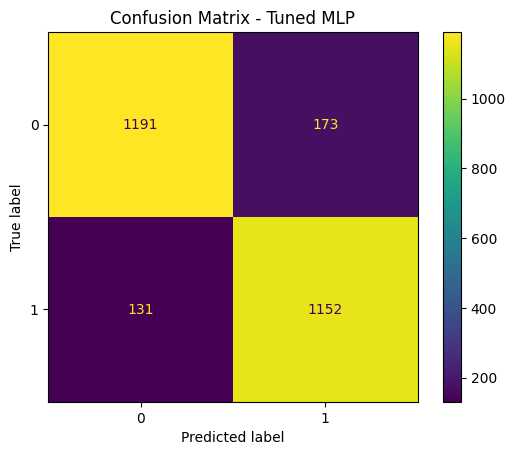

In [ ]:
# Display confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned)
disp.plot()
plt.title("Confusion Matrix - Tuned MLP")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1364
           1       0.87      0.90      0.88      1283

    accuracy                           0.89      2647
   macro avg       0.89      0.89      0.89      2647
weighted avg       0.89      0.89      0.89      2647



### Hyperparameter Tuning Interpretation

After tuning, I compare the tuned MLP model against the baseline MLP model.

The purpose of tuning is not only to improve performance, but also to confirm whether the baseline model was already near optimal. If the tuned model improves F1, recall, or ROC-AUC, then the tuning process helped the model generalize better. If the improvement is small, that still shows the original MLP structure was already strong.

For this project, recall remains especially important because a false negative means the model failed to identify a county that is actually high risk.

### Hyperparameter Tuning Results and Interpretation

The tuned MLP model produced slightly different results compared to the baseline model.

While overall accuracy and precision decreased slightly, recall improved from 0.887 to 0.898. This means the tuned model is better at identifying high-violence counties and reduces the number of false negatives.

In this problem context, recall is especially important because failing to identify a high-risk county could prevent early intervention and resource allocation.

The confusion matrix confirms this improvement: the number of missed high-violence counties (false negatives) decreased after tuning.

However, this came at the cost of increased false positives, meaning more counties are incorrectly flagged as high risk.

This trade-off reflects a common pattern in classification models, where improving recall can reduce precision.

### Conclusion of Tuning

Although the baseline model had slightly higher overall accuracy and F1 score, the tuned model provides better recall, which may be more valuable for real-world decision-making.

Therefore, the choice between models depends on the priority:
- Baseline MLP → better overall balance
- Tuned MLP → better at identifying high-risk counties

For this project, the tuned model offers a meaningful improvement in recall, aligning with the goal of minimizing missed high-risk counties.

## 7. Feature Importance (Permutation Importance)

Unlike models such as Logistic Regression or Random Forest, neural networks do not provide direct feature importance scores.

To interpret the model, we use **Permutation Importance**.

### What is Permutation Importance?

Permutation importance measures how much model performance decreases when a feature’s values are randomly shuffled.

- If shuffling a feature causes a large drop in performance → the feature is important  
- If performance stays the same → the feature is not important  

### Why this method?

- Works with any model (including neural networks)
- Does not rely on model structure
- Provides a direct measure of impact on predictions

In this section, we identify the most important features that influence whether a county is classified as high or low gun violence.

In [ ]:
# Compute permutation importance on the TEST set
# Using the tuned model (best version)

perm_importance = permutation_importance(
    best_mlp,                 # tuned model
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1",
    n_jobs=-1
)

In [ ]:
# Create a DataFrame for easier analysis
feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

# Show top 10 features
feature_importance_df.head(10)

,feature,importance
0,population,0.387798
20,RPL_THEMES,0.137330
1,was_suppressed,0.095369
9,svi_minority,0.025557
21,svi_poverty_rate,0.023599
5,svi_age65_plus,0.019884
16,RPL_THEME1,0.015311
7,svi_disabled,0.011273
6,svi_age17_under,0.009237
19,RPL_THEME4,0.008774


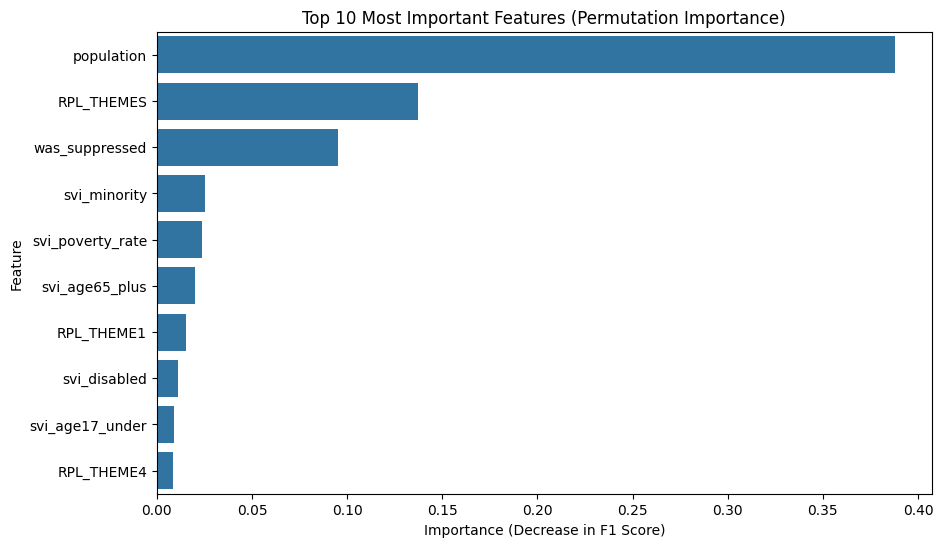

In [ ]:
# Plot top 10 features
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top 10 Most Important Features (Permutation Importance)")
plt.xlabel("Importance (Decrease in F1 Score)")
plt.ylabel("Feature")
plt.show()

### Feature Importance Interpretation

Using permutation importance, we identified the top features that most strongly influence whether a county is classified as high gun violence.

The top 10 most important features are:

1. population  
2. RPL_THEMES (overall social vulnerability index)  
3. was_suppressed  
4. svi_minority  
5. svi_poverty_rate  
6. svi_age65_plus  
7. RPL_THEME1 (socioeconomic status)  
8. svi_disabled  
9. svi_age17_under  
10. RPL_THEME4 (housing and transportation vulnerability)  

### Key Insights

The results show that **overall social vulnerability (RPL_THEMES)** and multiple SVI-related variables (poverty rate, minority status, disability, and age structure) play a significant role in predicting gun violence.

This suggests that **structural and socioeconomic disadvantage** is strongly associated with higher levels of gun violence.

### Important Considerations

Two features require careful interpretation:

- **Population** is the most important feature by a large margin. This likely reflects that larger counties tend to have more complex social dynamics and higher exposure to risk factors. However, it may also indicate that population size is acting as a proxy for urbanization rather than a direct cause of gun violence.

- **was_suppressed** appears as an important feature, but this variable is related to data reporting (suppressed counts for low values). This suggests the model may be partially learning patterns in the data collection process rather than real-world risk factors.

### Interpretation of Social Drivers

Excluding these two variables, the remaining top features consistently point toward:

- Poverty and economic disadvantage  
- Minority population composition  
- Age structure (youth and elderly populations)  
- Disability and vulnerability  
- Housing and transportation instability  

These factors align with existing public health research showing that **gun violence is strongly correlated with social vulnerability and economic inequality**.

### Real-World Implications

The model suggests that counties with higher social vulnerability are more likely to experience high levels of gun violence.

This insight can help policymakers:

- Prioritize high-risk counties for intervention  
- Allocate resources such as mental health services and violence prevention programs  
- Focus on addressing root causes such as poverty, housing instability, and lack of economic opportunity  

Overall, the neural network reinforces the idea that gun violence is not random, but deeply connected to underlying social and economic conditions.